# Домашнее задание: Physics-Informed Neural Networks (PINNs)
В этой домашней работе мы:
- Решим **прямую задачу**: получим решение уравнения теплопроводности
- Решим **обратную задачу**: восстановим функцию источника тепла из решения прямой задачи и из точного решения.

---

## Задача: Уравнение теплопроводности

Рассмотрим 1D уравнение теплопроводности:

$$
\frac{\partial u}{\partial t} = \frac{\partial^2 u}{\partial x^2} + \cos(2 \pi x), \quad x \in [0, 1], \ t \ge 0
$$

Начальные условия: $u(x, 0) = \sin^2(3 \pi x)$  
Граничные условия: $\left. \frac{\partial u(x, t)}{\partial x} \right|_{x=0} = \left. \frac{\partial u(x, t)}{\partial x} \right|_{x=1} = 0$

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Класс модели PINN

In [102]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(2, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1)
                      )

    def forward(self, x):
        return self.model(x)

Выполнение уравнения

In [3]:
def pde_residual(model, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    inputs = torch.cat([x, t], dim=1)
    u = model(inputs)

    u_t = grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    return u_t - u_xx - torch.cos(2 * np.pi * x)

def analytical_solution(x, t):
    return 1/2 * ( -torch.exp(- 4 * np.pi**2 * t) *torch.cos(2 * np.pi * x) / (2 * np.pi**2) + (2 * (np.pi)**2 + torch.cos(2 * np.pi * x)) / (2 * np.pi**2) - torch.exp(-36 * np.pi**2 * t) * torch.cos(6 * np.pi * x))

## **Прямая задача (Forward Problem)**

В прямой задаче решается классическая задача Коши для одномерного уравнения теплопроводности. Источник тепла известен.

Хотим найти функцию $u(x, t)$, удовлетворяющую начальным, граничным условиям и уравнению теплопроводности.

#### Метод:

* Нейросеть $u_\theta(x, t)$ обучается за счёт минимизации следующей функции потерь:

$$
\mathcal{L}_{\text{Total}} = \mathcal{L}_{\text{IC}} + \mathcal{L}_{\text{BC}} + \mathcal{L}_{\text{PDE}}
$$

где

$$
\mathcal{L}_{\text{IC}} = \frac{1}{N_{\text{IC}}} \sum_{i=1}^{N_{\text{IC}}} \left(u_\theta(x_i, 0) - \sin^2(3 \pi x)\right)^2
$$

$$
\mathcal{L}_{\text{BC}} = \frac{1}{N_{\text{BC}}} \sum_{i=1}^{N_{\text{BC}}} \left(\left. \left( \frac{\partial u_\theta(x_i, t_i)}{\partial x} \right|_{x=0}\right)^2 + \left. \left(\frac{\partial u_\theta(x_i, t_i)}{\partial x} \right|_{x=1} \right)^2\right)
$$

$$
\mathcal{L}_{\text{PDE}} = \frac{1}{N_{\text{PDE}}} \sum_{i=1}^{N_{\text{PDE}}} \left( \frac{\partial u_\theta}{\partial t}(x_i, t_i) - \frac{\partial^2 u_\theta}{\partial x^2}(x_i, t_i) - \cos(2 \pi x)\right)^2
$$



### Обучение Forward PINN (2 балла)

Обучите Forward PINN и восстановите $u(x,t)$, сравните его с точным решением. Обратите внимание, что в этом пункте для обучения PINN запрещено использовать аналитическое решение. Модель не должна знать ничего кроме уравнений и условий к нему.

In [109]:
def initial_condition(x):
    return torch.sin(3 * torch.pi * x) ** 2

def boundary_condition(model, x, t):
    x.requires_grad_(True)
    inputs = torch.cat([x, t], dim=1)
    u = model(inputs)

    u_x = grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    return u_x


def train_forward(model, n_ic=200, n_bc=200, n_pde=2000, epochs=15000, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=500,
    )

    x_ic = torch.rand(n_ic, 1).to(device)
    t_ic = torch.zeros_like(x_ic).to(device)
    u_ic = initial_condition(x_ic)

    t_bc = torch.rand(n_bc, 1).to(device)
    x_bc_0 = torch.zeros_like(t_bc).to(device)
    x_bc_1 = torch.ones_like(t_bc).to(device)

    x_pde = torch.rand(n_pde, 1).to(device)
    t_pde = torch.rand(n_pde, 1).to(device)

    for epoch in range(epochs):
        optimizer.zero_grad()

        # IC loss

        u_ic_pred = model(torch.cat([x_ic, t_ic], dim=1))
        loss_ic = nn.MSELoss()(u_ic_pred, u_ic)

        # BC loss

        loss_bc0 = torch.mean(boundary_condition(model, x_bc_0, t_bc) ** 2)
        loss_bc1 = torch.mean(boundary_condition(model, x_bc_1, t_bc) ** 2)
        loss_bc = loss_bc0 + loss_bc1

        # PDE residual loss

        res_pde = pde_residual(model, x_pde, t_pde)
        loss_pde = torch.mean(res_pde ** 2)

        loss = 30 * loss_ic + loss_bc + loss_pde
        loss1 = loss_ic + loss_bc + loss_pde
        loss.backward()
        optimizer.step()

        scheduler.step(loss)

        if epoch % 100 == 0:
            print(f"[Epoch {epoch}] Loss: {loss1.item():.5f} (IC: {loss_ic:.5f}, BC: {loss_bc:.5f}, PDE: {loss_pde:.5f})")

        losses.append(loss.item())

    return losses

[Epoch 0] Loss: 0.91445 (IC: 0.41888, BC: 0.00013, PDE: 0.49544)
[Epoch 100] Loss: 0.62769 (IC: 0.12326, BC: 0.00731, PDE: 0.49712)
[Epoch 200] Loss: 0.62409 (IC: 0.12314, BC: 0.00635, PDE: 0.49460)
[Epoch 300] Loss: 0.61512 (IC: 0.12284, BC: 0.00641, PDE: 0.48587)
[Epoch 400] Loss: 0.43245 (IC: 0.12245, BC: 0.02718, PDE: 0.28283)
[Epoch 500] Loss: 0.15181 (IC: 0.12180, BC: 0.01510, PDE: 0.01491)
[Epoch 600] Loss: 0.15521 (IC: 0.12112, BC: 0.02551, PDE: 0.00859)
[Epoch 700] Loss: 0.15385 (IC: 0.12080, BC: 0.02686, PDE: 0.00619)
[Epoch 800] Loss: 0.15162 (IC: 0.12059, BC: 0.02583, PDE: 0.00519)
[Epoch 900] Loss: 0.15002 (IC: 0.12040, BC: 0.02533, PDE: 0.00429)
[Epoch 1000] Loss: 0.15035 (IC: 0.12024, BC: 0.02550, PDE: 0.00461)
[Epoch 1100] Loss: 0.15052 (IC: 0.12014, BC: 0.02578, PDE: 0.00460)
[Epoch 1200] Loss: 0.15045 (IC: 0.12004, BC: 0.02552, PDE: 0.00489)
[Epoch 1300] Loss: 0.14964 (IC: 0.11999, BC: 0.02494, PDE: 0.00470)
[Epoch 1400] Loss: 0.14960 (IC: 0.11990, BC: 0.02469, PDE: 0

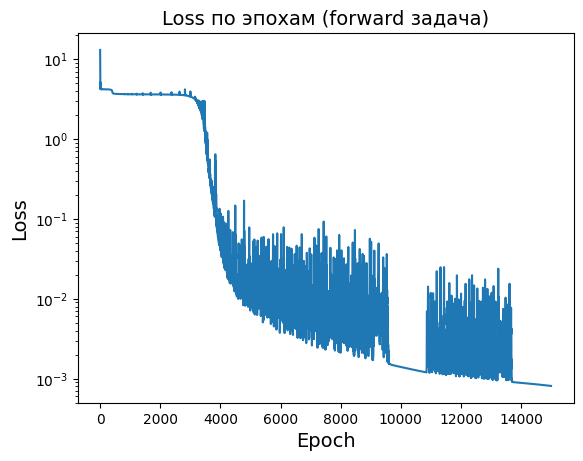

In [110]:
model_forward = PINN().to(device)

losses_forward = train_forward(model_forward)

plt.plot(losses_forward)
plt.title("Loss по эпохам (forward задача)", fontsize=14)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Loss", fontsize=14)
plt.yscale("log")
plt.show()

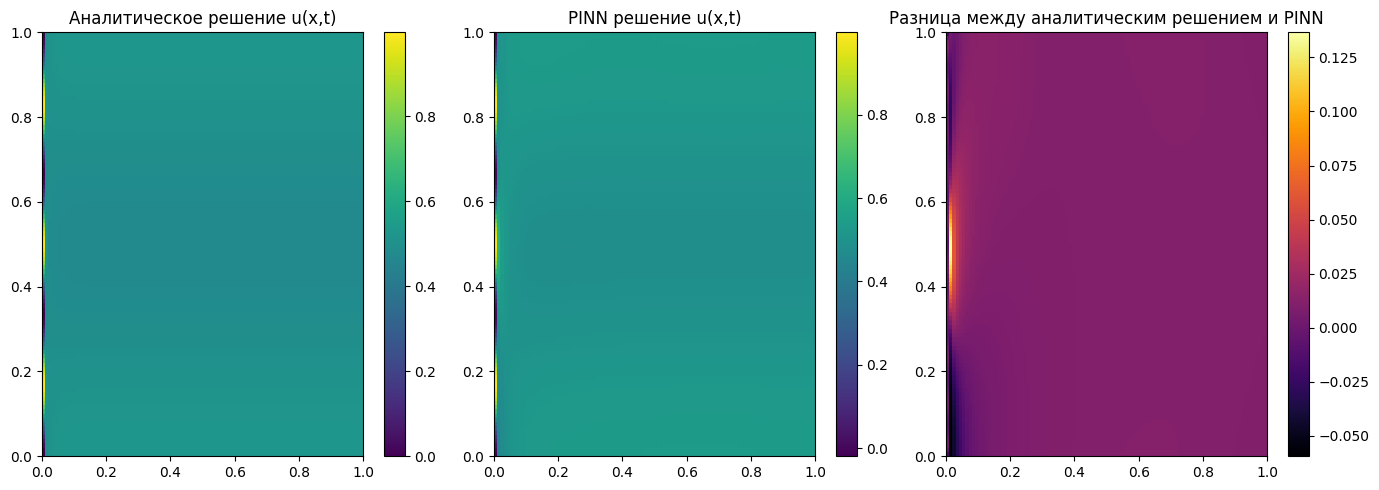

In [111]:
# Создание сетки
x_grid = torch.linspace(0, 1, 100).reshape(-1, 1)
t_grid = torch.linspace(0, 1, 100).reshape(-1, 1)
x_mesh, t_mesh = torch.meshgrid(x_grid.squeeze(), t_grid.squeeze(), indexing='ij')
x_flat = x_mesh.reshape(-1, 1).to(device)
t_flat = t_mesh.reshape(-1, 1).to(device)

# Аналитическое решение
u_exact = analytical_solution(x_flat, t_flat).cpu().detach().numpy().reshape(100, 100)

# PINN решение
with torch.no_grad():
    u_pred = model_forward(torch.cat([x_flat, t_flat], dim=1)).cpu().numpy().reshape(100, 100)

# Визуализация
fig, axs = plt.subplots(1, 3, figsize=(14, 5))

c1 = axs[0].imshow(u_exact, extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
axs[0].set_title("Аналитическое решение u(x,t)")
fig.colorbar(c1, ax=axs[0])

c2 = axs[1].imshow(u_pred, extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
axs[1].set_title("PINN решение u(x,t)")
fig.colorbar(c2, ax=axs[1])

c3 = axs[2].imshow(u_pred - u_exact, extent=[0,1,0,1], origin='lower', aspect='auto', cmap='inferno')
axs[2].set_title("Разница между аналитическим решением и PINN")
fig.colorbar(c3, ax=axs[2])

plt.tight_layout()
plt.show()

## **Обратная задача (Inverse Problem)**

В обратной задаче предполагается, что функция источника тепла неизвестна, и ее необходимо восстановить.

У нас есть наблюдаемые значения функции $u(x, t)$ в ограниченном числе точек: $$\{(x_i, t_i, u_i^{\text{obs}})\}_{i=1}^{N_{\text{obs}}}$$

Хотим восстановить $f(x)$ по наблюдаемым данным.

#### Метод:

Обучаем нейросеть $u_\theta(x, t)$ и оптимизируем параметр $f(x)$, минимизируя:

$$
\mathcal{L}_{\text{Total}} = \mathcal{L}_{\text{data}} + \mathcal{L}_{\text{PDE}}
$$

где

$$
\mathcal{L}_{\text{data}} = \frac{1}{N_{\text{obs}}} \sum_{i=1}^{N_{\text{obs}}} \left(u_\theta(x_i, t_i) - u_i^{\text{obs}}\right)^2
$$

$$
\mathcal{L}_{\text{PDE}} = \frac{1}{N_{\text{PDE}}} \sum_{i=1}^{N_{\text{PDE}}} \left( \frac{\partial u_\theta}{\partial t}(x_i, t_i) - \frac{\partial^2 u_\theta}{\partial x^2}(x_i, t_i) - f(x)\right)^2
$$



### Обучение Inverse PINN на основе аналитического результата (4 балла)

Обучите нейронную сеть восстанавливать $f(x)$ из аналитического решения. Можете пользоваться любыми хаками и улучшениями, но главное -- не показывать нейронной сети информацию об $f(x)$.
P.S. возможно, вам потребуется поменять архитектуру нейронной сети, чтобы на выходе помимо $u(x,t)$ выдавалась $f(x)$. Можете пойти и другим путем, например, создать отдельную маленькую нейронную сеть для $f(x)$, которая будет принимать на вход, соответственно, только $x$. Feel free to experiment

In [171]:
class SinActivation(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return torch.sin(x)

class PINN_Sin(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(2, 50),
            SinActivation(),
            nn.Linear(50, 50),
            SinActivation(),
            nn.Linear(50, 50),
            SinActivation(),
            nn.Linear(50, 50),
            SinActivation(),
            nn.Linear(50, 50),
            SinActivation(),
            nn.Linear(50, 1)
                      )

    def forward(self, x):
        return self.model(x)

class Source(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(1, 50),
            SinActivation(),
            nn.Linear(50, 50),
            SinActivation(),
            nn.Linear(50, 1)
                      )

    def forward(self, x):
        return self.model(x)

In [130]:
def pde_residual_inv(model_u, model_f, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)
    inputs = torch.cat([x, t], dim=1)
    u = model_u(inputs)
    f = model_f(x)

    u_t = grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_x = grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]

    return u_t - u_xx - f

In [131]:
def generate_data_points(n_obs, n_pde):
    x_obs = torch.rand(n_obs, 1)
    t_obs = torch.rand(n_obs, 1)
    x_pde = torch.rand(n_pde, 1)
    t_pde = torch.rand(n_pde, 1)
    return x_obs, t_obs, x_pde, t_pde

In [187]:
def train_inverse(model_u, model_f, n_obs=10000, n_pde=5000):
    x_obs, t_obs, _, _ = generate_data_points(n_obs, n_pde)
    x_obs, t_obs = x_obs.to(device), t_obs.to(device)
    u_obs = analytical_solution(x_obs, t_obs).detach().to(device)

    optimizer = torch.optim.Adam(list(model_u.parameters()) + list(model_f.parameters()), lr=1e-3)

    for epoch in range(5000):
        optimizer.zero_grad()

        x_pde = torch.rand(n_pde, 1).to(device)
        t_pde = torch.rand(n_pde, 1).to(device)

        res_pde = pde_residual_inv(model_u, model_f, x_pde, t_pde)
        loss_pde = torch.mean(res_pde ** 2)

        u_pred = model_u(torch.cat([x_obs, t_obs], dim=1))
        loss_data = nn.MSELoss()(u_pred, u_obs)

        loss = loss_pde + 100000.0 * loss_data

        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print(f"[Epoch {epoch}] Loss: {loss.item():.5f} (Data: {loss_data:.5f}, PDE: {loss_pde:.5f})")

    optimizer_lbfgs = torch.optim.LBFGS(
        list(model_u.parameters()) + list(model_f.parameters()),
        lr=1.0, max_iter=10000, history_size=100, line_search_fn="strong_wolfe"
    )

    x_pde_l = torch.rand(10000, 1).to(device)
    t_pde_l = torch.rand(10000, 1).to(device)

    def closure():
        optimizer_lbfgs.zero_grad()
        res_pde = pde_residual_inv(model_u, model_f, x_pde_l, t_pde_l)
        loss_pde = torch.mean(res_pde ** 2)
        u_pred = model_u(torch.cat([x_obs, t_obs], dim=1))
        loss_data = nn.MSELoss()(u_pred, u_obs)
        loss = 1.0 * loss_pde + 100000.0 * loss_data # БЕЗ BC
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)
    print(f"Final Loss: {closure().item()}")


    return model_u, model_f

In [188]:
model_inverse_1 = PINN_Sin().to(device)
model_f = Source().to(device)

model_inverse_1, model_f = train_inverse(model_inverse_1, model_f)

[Epoch 0] Loss: 28666.82031 (Data: 0.28667, PDE: 0.00598)
[Epoch 500] Loss: 58.92131 (Data: 0.00059, PDE: 0.00017)
[Epoch 1000] Loss: 46.51363 (Data: 0.00047, PDE: 0.00015)
[Epoch 1500] Loss: 27.17622 (Data: 0.00027, PDE: 0.00006)
[Epoch 2000] Loss: 27.14323 (Data: 0.00027, PDE: 0.00005)
[Epoch 2500] Loss: 27.07260 (Data: 0.00027, PDE: 0.00005)
[Epoch 3000] Loss: 27.03090 (Data: 0.00027, PDE: 0.00006)
[Epoch 3500] Loss: 26.98646 (Data: 0.00027, PDE: 0.00008)
[Epoch 4000] Loss: 26.93491 (Data: 0.00027, PDE: 0.00010)
[Epoch 4500] Loss: 26.86964 (Data: 0.00027, PDE: 0.00015)
Final Loss: 17.876176834106445


#### Запуск и визуализация результатов

Визуализируйте результаты, нарисуйте на одном графике $f(x)$, полученную при помощи PINN и сравните его с точной функцией источника тепла $f(x) = \cos(2 \pi x)$.

<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-1484103497.py:8: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(x_plot.cpu().numpy(), f_exact, label='$f(x) = cos(2 \pi x)$')


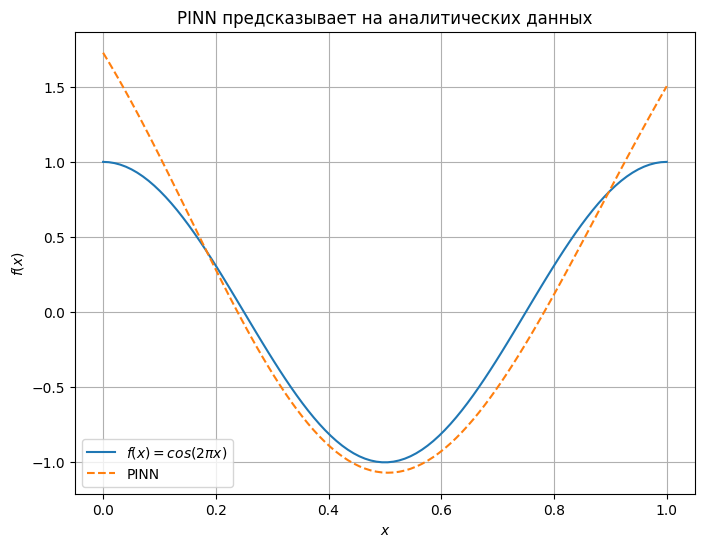

In [189]:
x_plot = torch.linspace(0, 1, 100).reshape(-1, 1).to(device)
f_exact = torch.cos(2 * torch.pi * x_plot).cpu().detach().numpy()

with torch.no_grad():
    f_pred = model_f(x_plot).cpu().numpy()

plt.figure(figsize=(8, 6))
plt.plot(x_plot.cpu().numpy(), f_exact, label='$f(x) = cos(2 \pi x)$')
plt.plot(x_plot.cpu().numpy(), f_pred, label='PINN', linestyle='--')
plt.title('PINN предсказывает на аналитических данных')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()
plt.grid(True)
plt.show()

### Inverse PINN на основе ответов Forward PINN (4 балла)

Обучите обратный PINN на основе ответов Forward PINN. Соответственно, Forward PINN знает об источнике тепла, а обратный PINN пытается его восстановить.

In [190]:
def train_inverse_2(model_u, model_f, n_obs=10000, n_pde=5000):
    x_obs, t_obs, _, _ = generate_data_points(n_obs, n_pde)
    x_obs, t_obs = x_obs.to(device), t_obs.to(device)
    u_obs = model_forward(torch.cat([x_obs, t_obs], dim=1)).detach()

    optimizer = torch.optim.Adam(list(model_u.parameters()) + list(model_f.parameters()), lr=1e-3)

    optimizer = torch.optim.Adam(list(model_u.parameters()) + list(model_f.parameters()), lr=1e-3)

    for epoch in range(5000):
        optimizer.zero_grad()

        x_pde = torch.rand(n_pde, 1).to(device)
        t_pde = torch.rand(n_pde, 1).to(device)

        res_pde = pde_residual_inv(model_u, model_f, x_pde, t_pde)
        loss_pde = torch.mean(res_pde ** 2)

        u_pred = model_u(torch.cat([x_obs, t_obs], dim=1))
        loss_data = nn.MSELoss()(u_pred, u_obs)

        loss = loss_pde + 100000.0 * loss_data

        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print(f"[Epoch {epoch}] Loss: {loss.item():.5f} (Data: {loss_data:.5f}, PDE: {loss_pde:.5f})")

    optimizer_lbfgs = torch.optim.LBFGS(
        list(model_u.parameters()) + list(model_f.parameters()),
        lr=1.0, max_iter=10000, history_size=100, line_search_fn="strong_wolfe"
    )

    x_pde_l = torch.rand(10000, 1).to(device)
    t_pde_l = torch.rand(10000, 1).to(device)

    def closure():
        optimizer_lbfgs.zero_grad()
        res_pde = pde_residual_inv(model_u, model_f, x_pde_l, t_pde_l)
        loss_pde = torch.mean(res_pde ** 2)
        u_pred = model_u(torch.cat([x_obs, t_obs], dim=1))
        loss_data = nn.MSELoss()(u_pred, u_obs)
        loss = 1.0 * loss_pde + 100000.0 * loss_data # БЕЗ BC
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)
    print(f"Final Loss: {closure().item()}")

    return model_u, model_f

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-2984029033.py:10: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(x_plot.cpu().numpy(), f_exact, label='$f(x) = cos(2 \pi x)$')


[Epoch 0] Loss: 20741.84766 (Data: 0.20742, PDE: 0.15575)
[Epoch 500] Loss: 68.81210 (Data: 0.00069, PDE: 0.00014)
[Epoch 1000] Loss: 44.17797 (Data: 0.00044, PDE: 0.00521)
[Epoch 1500] Loss: 42.19005 (Data: 0.00042, PDE: 0.00710)
[Epoch 2000] Loss: 41.43617 (Data: 0.00041, PDE: 0.00964)
[Epoch 2500] Loss: 40.10699 (Data: 0.00040, PDE: 0.01443)
[Epoch 3000] Loss: 39.12282 (Data: 0.00039, PDE: 0.02643)
[Epoch 3500] Loss: 38.63678 (Data: 0.00039, PDE: 0.05024)
[Epoch 4000] Loss: 36.83319 (Data: 0.00037, PDE: 0.05935)
[Epoch 4500] Loss: 35.06077 (Data: 0.00035, PDE: 0.07650)
Final Loss: 0.08973339200019836


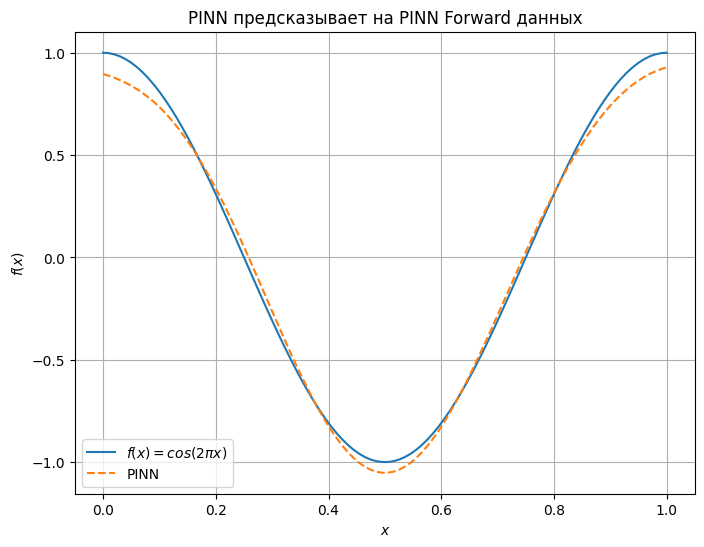

In [191]:
model_inverse_2 = PINN().to(device)
model_f_2 = Source().to(device)

model_inverse_2, model_f_2 = train_inverse_2(model_inverse_2, model_f_2)

with torch.no_grad():
    f_pred = model_f_2(x_plot).cpu().numpy()

plt.figure(figsize=(8, 6))
plt.plot(x_plot.cpu().numpy(), f_exact, label='$f(x) = cos(2 \pi x)$')
plt.plot(x_plot.cpu().numpy(), f_pred, label='PINN', linestyle='--')
plt.title('PINN предсказывает на PINN Forward данных')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.legend()
plt.grid(True)
plt.show()